# Data Ingestion, Profiling & Cleaning

**Goal:** Convert the 7 raw, heterogeneous CSV files from `data/raw` into a single,
enriched, model‑ready dataset and persist it for the next stages of the pipeline.

**What this stage actually does:**

1. **Scans & detects columns** – flexibly maps each CSV’s label, subject and body
   columns using predefined candidate lists.
2. **Standardises labels** – converts variations like “phishing”, “spam”, “1”, … to `1`
   and “legitimate”, “ham”, “0”, … to `0` via `normalize_label`.
3. **Builds `raw_text`** – concatenates subject and body with a newline separator.
4. **Merges & does basic cleaning** – combines all files, drops rows with missing
   labels, empty text, and exact duplicate (text, label) pairs.
5. **Profiles the data** – reports row counts, label distribution, column mapping
   per file, and missing values.
6. **Applies enhanced linguistic cleaning**:
   - Decodes HTML entities and removes tags.
   - Lowercases the text.
   - Keeps informative symbols like `@`, `=?`, `!`, `$`, `/`, etc for the `raw_text` column to be used to train the `model_a`.
   - Removes English stopwords (via `sklearn`’s `ENGLISH_STOP_WORDS`).
7. **Creates the final `cleaned_text` column** – the cleaned, stopword‑free text
   ready for feature extraction.
8. **Saves the processed dataset** to `data/preprocessed/processed_data.csv`.

**Output:** A CSV file containing the following columns:
- `source_file` – original filename
- `label` – binary 0/1
- `subject`, `body` – raw metadata (kept for reference)
- `raw_text` – subject + body combined
- `cleaned_text` – enhanced‑cleaned text without stopword removal (if present)

**`cleaned_text`** – fully cleaned text with stopwords removed, the direct input
  for Model B

## 1) Setting Up the Project Root in a Notebook
To ensure everything is not missed we will:
- Starts from the notebook's current directory.
- Moves up the directory tree until it finds a folder named `model_a`, which is assumed to be a direct child of the project root.
- Adds that project root to `sys.path` so Python can import packages and modules (like `model_a`) correctly.
- Prints the resolved root for verification.

This ensures all file paths and imports are consistent regardless of which subfolder the notebook is opened from.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'model_a').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)


Project root: C:\Work\current\phishing_detection


## 2) Data Ingestion & Heterogeneous Sourcing:
### 2.1. Imports and Constants
Import required libraries and define the lists of values that will be used
to recognise `phishing/legitimate` labels later.

In [3]:
import math
from pathlib import Path
import pandas as pd

LABEL_TRUE_VALUES = {"1", "true", "yes", "phishing", "spam", "malicious"}
LABEL_FALSE_VALUES = {"0", "false", "no", "legitimate", "legit", "ham", "benign"}

### 2.2. Candidate Column Names
Define the possible column names we expect for label, subject and body.
The `pick_column` helper will look for these when standardising a DataFrame.

In [4]:
LABEL_CANDIDATES = ["label", "class", "class_label", "is_phishing", "phishing"]
SUBJECT_CANDIDATES = ["subject", "subj", "email_subject", "subject_line"]
BODY_CANDIDATES = ["body", "text", "content", "message", "email_body", "raw_text", "text_combined"]

### 2.3. Text Cleaning Utilities
- `safe_text`: converts any value (including `None`/`NaN`) to a string.
- `combine_subject_body`: merges subject and body with a newline if both are present.
- `normalize_columns`: lowercases and strips column names for reliable matching.
- `pick_column`: picks the first matching column from the candidates list.

In [5]:
def safe_text(value: object) -> str:
    if value is None:
        return ""
    if isinstance(value, float) and math.isnan(value):
        return ""
    return str(value)


def combine_subject_body(subject: object, body: object) -> str:
    subject_text = safe_text(subject).strip()
    body_text = safe_text(body).strip()
    if subject_text and body_text:
        return f"{subject_text}\n{body_text}"
    return subject_text or body_text


def normalize_columns(columns) -> list[str]:
    return [safe_text(col).strip().lower() for col in columns]


def pick_column(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None

### 2.4. Label Normalisation
`normalize_label` converts ambiguous label representations (strings,
booleans, integers) into a clean 1 (phishing) / 0 (legitimate) integer,
or `None` if the value cannot be interpreted.

In [6]:
def normalize_label(value: object) -> int | None:
    if value is None:
        return None
    if isinstance(value, float) and math.isnan(value):
        return None
    if isinstance(value, str):
        normalized = value.strip().lower()
        if normalized in LABEL_TRUE_VALUES:
            return 1
        if normalized in LABEL_FALSE_VALUES:
            return 0
    try:
        int_value = int(value)
    except (TypeError, ValueError):
        return None
    return 1 if int_value == 1 else 0 if int_value == 0 else None

### 2.5. Standardise a Single DataFrame
`standardize_email_dataframe` takes a raw DataFrame from one CSV file,
renames columns, extracts label/subject/body, and returns a consistent
DataFrame with columns `source_file`, `label`, `subject`, `body` and `raw_text`.

**Note:** `raw_text` is a new create column by mergin both body and subject in one block.

In [7]:
def standardize_email_dataframe(df: pd.DataFrame, source_file: str) -> pd.DataFrame:
    df = df.copy()
    df.columns = normalize_columns(df.columns)
    columns = df.columns.tolist()

    label_col = pick_column(columns, LABEL_CANDIDATES)
    subject_col = pick_column(columns, SUBJECT_CANDIDATES)
    body_col = pick_column(columns, BODY_CANDIDATES)

    if label_col is None:
        raise KeyError(f"{source_file}: no label column found")
    if subject_col is None and body_col is None:
        raise KeyError(f"{source_file}: no subject/body/text column found")

    df = df.reset_index(drop=True)
    row_count = len(df)
    subject = df[subject_col] if subject_col else pd.Series([""] * row_count, index=df.index)
    body = df[body_col] if body_col else pd.Series([""] * row_count, index=df.index)

    standardized = pd.DataFrame(
        {
            "source_file": source_file,
            "label": df[label_col].map(normalize_label),
            "subject": subject.fillna("").astype(str),
            "body": body.fillna("").astype(str),
        }
    )
    standardized["raw_text"] = [
        combine_subject_body(subject, body)
        for subject, body in zip(standardized["subject"], standardized["body"], strict=False)
    ]
    return standardized

### 2.6. Load, Inspect & Merge the Full Raw Dataset
`load_raw_email_dataset` scans the folder of raw CSVs and for **each file**:

1. Reads the CSV.
2. Determines which columns map to `label`, `subject`, and `body` (using the candidate lists).
3. Prints those detected columns (if `verbose=True`), so you can verify the mapping.
4. Standardises the DataFrame.
5. Optionally samples rows.

After all files are processed, the individual DataFrames are concatenated,
cleaned (removes missing labels, empty text) and deduplicated.

In [8]:
def load_raw_email_dataset(
    raw_dir: str | Path,
    *,
    sample_per_file: int | None = None,
    random_state: int = 42,
    verbose: bool = False,
) -> pd.DataFrame:
    raw_path = Path(raw_dir)
    file_paths = sorted(raw_path.glob("*.csv"))
    if not file_paths:
        raise FileNotFoundError(f"No CSV files found in {raw_path}")

    frames: list[pd.DataFrame] = []
    for file_path in file_paths:
        df = pd.read_csv(file_path, encoding_errors="replace")
        
        norm_cols = normalize_columns(df.columns)
        detected_label = pick_column(norm_cols, LABEL_CANDIDATES)
        detected_subject = pick_column(norm_cols, SUBJECT_CANDIDATES)
        detected_body = pick_column(norm_cols, BODY_CANDIDATES)
        
        if verbose:
            print(f"\n--- {file_path.name} ---")
            print(f"  Label column   : {detected_label or 'NOT FOUND'}")
            print(f"  Subject column : {detected_subject or 'NOT FOUND'}")
            print(f"  Body column    : {detected_body or 'NOT FOUND'}")
        
        if sample_per_file is not None and len(df) > sample_per_file:
            df = df.sample(n=sample_per_file, random_state=random_state)
        frames.append(standardize_email_dataframe(df, file_path.name))

    merged = pd.concat(frames, ignore_index=True)
    merged = merged.dropna(subset=["label"])
    merged["label"] = merged["label"].astype(int)
    merged["raw_text"] = merged["raw_text"].fillna("").astype(str).str.strip()
    merged = merged[merged["raw_text"] != ""]
    merged = merged.drop_duplicates(subset=["raw_text", "label"]).reset_index(drop=True)
    return merged

## 2.7. Apply Standardization & Label Normalization – First Inspection
Now we **manually apply** the two core functions we built:

- `standardize_email_dataframe`:  
  Builds the `raw_text` column (subject + body) and normalises the label column using `normalize_label`.
- `normalize_label`:  
  Converts text labels (e.g. "phishing", "no", "1", 0) to a clean **1** (phishing) or **0** (legitimate) integer.

We load every CSV from `data/raw`, print the detected columns, then display:
- total number of rows
- distribution of the binary `label` (1/0)
- the first few rows with source file, label, subject and body
- a bar chart (histogram) to visualise the label balance

### 2.7.1 Load and Standardise Each CSV File
Loop through all `.csv` files in `data/raw`. For each file:

1. Read the raw CSV.
2. Apply `standardize_email_dataframe` – this:
   - Detects and renames the label, subject, and body columns.
   - Normalises the label (e.g. “phishing” → 1, “legitimate” → 0) using `normalize_label`.
   - Creates the `raw_text` column (subject + body combined).
3. Print the detected column mapping and label distribution for verification.

The standardised DataFrames are collected in a list called `frames`.

In [9]:
from pathlib import Path
import pandas as pd

RAW_DIR = PROJECT_ROOT / "data" / "raw"

frames = []

for csv_file in sorted(RAW_DIR.glob("*.csv")):
    print(f"\nProcessing: {csv_file.name}")
    df_raw = pd.read_csv(csv_file, encoding_errors="replace")
    
    df_std = standardize_email_dataframe(df_raw, csv_file.name)
    
    norm_cols = normalize_columns(df_raw.columns)
    print(f"  Label column   : {pick_column(norm_cols, LABEL_CANDIDATES)}")
    print(f"  Subject column : {pick_column(norm_cols, SUBJECT_CANDIDATES)}")
    print(f"  Body column    : {pick_column(norm_cols, BODY_CANDIDATES)}")
    print(f"  Rows in file   : {len(df_std)}")
    print(f"  Label counts   : {df_std['label'].value_counts().to_dict()}")
    
    frames.append(df_std)


Processing: CEAS_08.csv
  Label column   : label
  Subject column : subject
  Body column    : body
  Rows in file   : 39154
  Label counts   : {1: 21842, 0: 17312}

Processing: Enron.csv
  Label column   : label
  Subject column : subject
  Body column    : body
  Rows in file   : 29767
  Label counts   : {0: 15791, 1: 13976}

Processing: Ling.csv
  Label column   : label
  Subject column : subject
  Body column    : body
  Rows in file   : 2859
  Label counts   : {0: 2401, 1: 458}

Processing: Nazario.csv
  Label column   : label
  Subject column : subject
  Body column    : body
  Rows in file   : 1565
  Label counts   : {1: 1565}

Processing: Nigerian_Fraud.csv
  Label column   : label
  Subject column : subject
  Body column    : body
  Rows in file   : 3332
  Label counts   : {1: 3332}

Processing: phishing_email.csv
  Label column   : label
  Subject column : None
  Body column    : text_combined
  Rows in file   : 82486
  Label counts   : {1: 42891, 0: 39595}

Processing: Spam

### 2.7.2 Merge All Files into One DataFrame
Concatenate all the standardised DataFrames into a single `df`.
We use `ignore_index=True` to reset row numbering.

In [10]:
df = pd.concat(frames, ignore_index=True)
print(f"Total rows before cleaning: {len(df)}")

Total rows before cleaning: 164972


### 2.7.3 Basic Cleaning of the Merged Dataset
Perform three essential clean‑ups:

- **Drop rows** where the label could not be parsed (`NaN`).
- **Remove rows** with an empty `raw_text` (no subject or body).
- **Drop exact duplicate** text + label combinations (keep first occurrence).

After cleaning, print the final row count and label distribution.

In [11]:
# 1. Remove unlabeled rows
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

# 2. Remove rows with empty text
df = df[df["raw_text"].str.strip() != ""]

# 3. Drop duplicate (text, label) pairs
df = df.drop_duplicates(subset=["raw_text", "label"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")
print("Label counts:")
print(df["label"].value_counts().sort_index())

Rows after cleaning: 164468
Label counts:
label
0    78821
1    85647
Name: count, dtype: int64


### 2.7.4 First Look at the Data
- Display the first few rows **including the combined `raw_text`**.
- Show a short snippet of the actual text to verify the subject‑body merge.
- Plot a bar chart of the label distribution (phishing vs. legitimate).

Table preview:

First 5 rows (source_file, label, subject, body, raw_text):


,source_file,label,subject,body,raw_text
0,CEAS_08.csv,1,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...","Never agree to be a loser\nBuck up, your troub..."
1,CEAS_08.csv,1,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,Befriend Jenna Jameson\nUpgrade your sex and p...
2,CEAS_08.csv,1,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,CNN.com Daily Top 10\n>+=+=+=+=+=+=+=+=+=+=+=+...
3,CEAS_08.csv,0,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,Re: svn commit: r619753 - in /spamassassin/tru...
4,CEAS_08.csv,1,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,SpecialPricesPharmMoreinfo\nWelcomeFastShippin...



Raw text snippet (only 200 charachters)

  Row 0: Never agree to be a loser
Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were roll...
  Row 1: Befriend Jenna Jameson
Upgrade your sex and pleasures with these techniques http://www.brightmade.com...
  Row 2: CNN.com Daily Top 10
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+...

Histogram


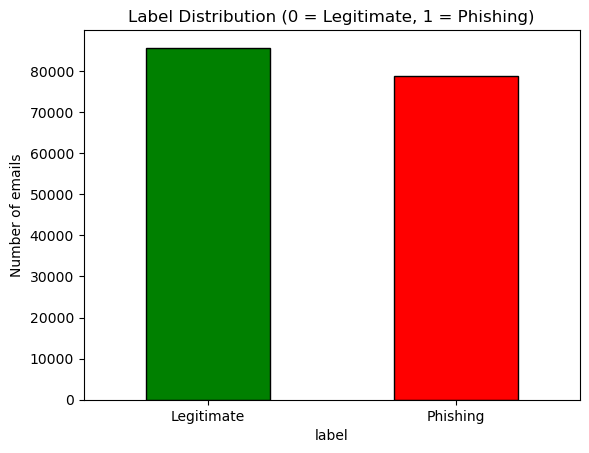

In [12]:
import matplotlib.pyplot as plt

print("Table preview:\n")
print("First 5 rows (source_file, label, subject, body, raw_text):")
display(df[["source_file", "label", "subject", "body", "raw_text"]].head())

print("\nRaw text snippet (only 200 charachters)\n")
for i, txt in enumerate(df["raw_text"].head(3)):
    print(f"  Row {i}: {txt[:200]}...")

print("\nHistogram")
df["label"].value_counts().plot(kind="bar", color=["green", "red"], edgecolor="black")
plt.title("Label Distribution (0 = Legitimate, 1 = Phishing)")
plt.xticks([0, 1], ["Legitimate", "Phishing"], rotation=0)
plt.ylabel("Number of emails")
plt.show()

**Remark:** we noticed that the data is balanced since there is not a big difference between **47.9%** and **52.1%**

## 2.8. Check for Missing Values
Before using the data for modelling, we verify how many values are missing
in each column. This helps us decide whether imputation, deletion or
feature‑engineering adjustments are needed.

In [13]:
print("Total rows:", len(df))
print("\nMissing values per column:")
missing = df.isnull().sum()
percent = (missing / len(df)) * 100
missing_info = pd.DataFrame({
    'missing_count': missing,
    'percent': percent.round(2)
})
print(missing_info.to_string())

Total rows: 164468

Missing values per column:
             missing_count  percent
source_file              0      0.0
label                    0      0.0
subject                  0      0.0
body                     0      0.0
raw_text                 0      0.0


**Remark:** As we see in the result of the previous cell, there is no missing value. Therefore, we do not need to do feature engineering to solve the problem of `NaN` values.

### Conclusion
The data ingestion stage successfully unified multiple heterogeneous sources into a standardized schema. By normalizing labels to a binary system (0: Legitimate, 1: Phishing) and combining email components into a single raw_text feature, we have established a high-integrity baseline. Statistical profiling confirms a balanced class distribution and zero null-value contamination, ensuring the dataset is structurally sound for the subsequent NLP preprocessing and vectorization phase

## 3) Advanced cleaning tasks
### 3.1. Enhanced Linguistic Cleaning (Model‑B Ready)
Our previous cleaner stripped everything except a‑z and spaces – good for
quick prototyping, but too aggressive for a “linguistic expert” model.

Here we upgrade the cleaning to:
- Decode HTML entities (`&amp;`, `&lt;`, etc.) with `html.unescape`.
- Remove English stopwords using `sklearn`’s built‑in list.

We’ll also create a dedicated column `cleaned_text` later, which will be the
final input to our model.

In [ ]:
import html
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Allow letters, digits, and selected symbols that carry meaning in emails
ALLOWED_TEXT_CHARS_RE = re.compile(r"[^a-z0-9]+")
HTML_TAG_RE           = re.compile(r"<[^>]+>")
WORD_KEY_RE           = re.compile(r"[^a-z0-9]+")
WHITESPACE_RE         = re.compile(r"\s+")

def clean_email_text(text: object, remove_stopwords: bool = True) -> str:
    cleaned = html.unescape(safe_text(text))
    cleaned = HTML_TAG_RE.sub(" ", cleaned)
    cleaned = cleaned.lower()
    cleaned = ALLOWED_TEXT_CHARS_RE.sub(" ", cleaned)
    cleaned = WHITESPACE_RE.sub(" ", cleaned).strip()

    # Stopword removal (done by default)
    if not remove_stopwords or not cleaned:
        return cleaned

    kept_tokens = []
    for token in cleaned.split():
        # Extract the plain alphabetic core (e.g., "hello!" -> "hello")
        word_key = WORD_KEY_RE.sub("", token)
        if word_key and word_key in ENGLISH_STOP_WORDS:
            continue
        kept_tokens.append(token)
    return " ".join(kept_tokens)

### 3.2. Build the Final `cleaned_text` Column
`add_cleaned_text` ensures we have a `raw_text` column (creates it if missing),
applies the enhanced cleaner, and stores the result in `cleaned_text`.
Rows where the resulting text is empty are dropped.

In [15]:
def add_cleaned_text(df: pd.DataFrame, remove_stopwords: bool = True) -> pd.DataFrame:
    """
    Add the column 'cleaned_text' to the DataFrame by cleaning 'raw_text'
    with the enhanced linguistic cleaner.
    """
    out = df.copy()
    # Ensure raw_text exists
    if "raw_text" not in out.columns:
        out["raw_text"] = [
            combine_subject_body(s, b)
            for s, b in zip(out["subject"], out["body"], strict=False)
        ]
    out["cleaned_text"] = out["raw_text"].map(
        lambda t: clean_email_text(t, remove_stopwords=remove_stopwords)
    )
    out = out[out["cleaned_text"] != ""].reset_index(drop=True)
    return out

### 3.3. Apply the Enhanced Cleaning (Stopwords Removed)
Now we use `add_cleaned_text` to create the final `cleaned_text` column.
Because `remove_stopwords=True` (default), common English stopwords
(the, is, and, etc.) will be removed from the text.

In [16]:
df = add_cleaned_text(df, remove_stopwords=True)

print("Rows after filtering:", len(df))
print("Label distribution:")
print(df["label"].value_counts().sort_index())

print("\nSample cleaned_text (first 200 chars):")
for i, txt in enumerate(df["cleaned_text"].head(3)):
    print(f"  Row {i}: {txt[:200]}...")

Rows after filtering: 164467
Label distribution:
label
0    78821
1    85646
Name: count, dtype: int64

Sample cleaned_text (first 200 chars):
  Row 0: agree loser buck troubles caused small dimension soon lover woman able resist http whitedone com come nazi tanks rolling streets dreamersphilosopher journalist sure...
  Row 1: befriend jenna jameson upgrade sex pleasures techniques http www brightmade com...
  Row 2: cnn com daily 10 daily 10 cnn com videos stories aug 1 2008 3 58 pm edt 10 videos 1 montauk monster http www cnn com video partners email index html url video 2008 07 31 moos montauk monster cnn devil...


### 3.4. Save the Processed Dataset
We persist the final DataFrame in `data/model_b/preprocessed/`.  
This folder keeps all **model‑B‑specific** prepared data separate from the  
raw and general processed folders.

The CSV contains:
- `source_file`, `subject`, `body` – original metadata
- `label` – binary 0 / 1
- `raw_text` – combined subject + body
- **cleaned_text`** – linguistically cleaned, stopword‑free final input

We drop the index for a clean reload later.

In [17]:
# Create the model‑b‑specific processed directory
processed_dir = PROJECT_ROOT / "data" / "preprocessed"
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "processed_data.csv"
df.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())

Dataset saved to: C:\Work\current\phishing_detection\data\preprocessed\processed_data.csv
Shape: (164467, 6)
Columns: ['source_file', 'label', 'subject', 'body', 'raw_text', 'cleaned_text']
